In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from tqdm import tqdm
from natsort import natsorted

pi = 3.14159265359

maxval=1e9
minval=1e-9

In [2]:
from dataloaders.OptimizedDataGenerator_v2p5 import OptimizedDataGenerator
#from models.mlp_encoder_model_nonquantized import *
from models.conv2d_model_nonquantized import *

2025-10-28 17:18:20.990263: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-10-28 17:18:21.632127: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


In [2]:
def get_all_losses(input_dir):
    checkpoints = natsorted(os.listdir(input_dir))
    train_losses = np.array([float(f.split('-t')[-1].split('-v')[0]) for f in checkpoints])
    validation_losses = np.array([float(f.split('-v')[-1].split('.hdf5')[0]) for f in checkpoints])

    return train_losses, validation_losses

In [3]:
train_losses1, validation_losses1 = get_all_losses('/data/dajiang/smart-pixels/weights/dataset_3src_16x16_weights/weights-50x12P5-bs5000-34c2da80-2t-conv2d_MAX-manual_input_digitization-noise-checkpoints')
train_losses2, validation_losses2 = get_all_losses('/data/dajiang/smart-pixels/weights/dataset_3src_16x16_weights/weights-50x12P5-bs5000-34c2da80-2t-conv2d_FULL-manual_input_digitization-noise-checkpoints')
train_losses3, validation_losses3 = get_all_losses('/data/dajiang/smart-pixels/weights/dataset_3src_16x16_weights/weights-50x12P5-bs5000-34c2da80-2t-mlp_FULL-manual_input_digitization-noise-checkpoints')
train_losses4, validation_losses4 = get_all_losses('/data/dajiang/smart-pixels/weights/dataset_3src_16x16_weights/weights-50x12P5-bs5000-34c2da80-2t-mlp_SLIM-manual_input_digitization-noise-checkpoints')

epochs1 = np.arange(1, len(train_losses1)+1, 1)
epochs2 = np.arange(1, len(train_losses2)+1, 1)
epochs3 = np.arange(1, len(train_losses3)+1, 1)
epochs4 = np.arange(1, len(train_losses4)+1, 1)

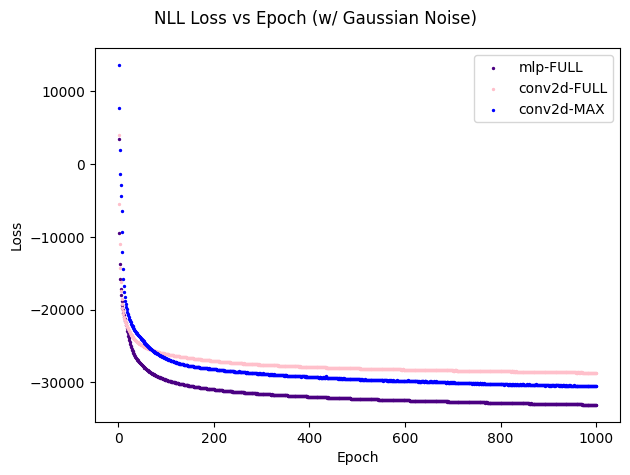

In [4]:
fig, ax = plt.subplots()

ax.scatter(x=epochs3, y=validation_losses3, s=2, c='indigo', label='mlp-FULL')
ax.scatter(x=epochs2, y=validation_losses2, s=2, c='pink', label='conv2d-FULL')
ax.scatter(x=epochs1, y=validation_losses1, s=2, c='blue', label='conv2d-MAX')

ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.legend()
fig.suptitle('NLL Loss vs Epoch (w/ Gaussian Noise)')
fig.tight_layout()
fig.savefig('/home/dajiang/smart-pixels-ml/plots/loss/loss_mlp-FULL_conv2d-FULL_conv2d-MAX_manual-input-digitization_noise.png', dpi=300)
fig.show()

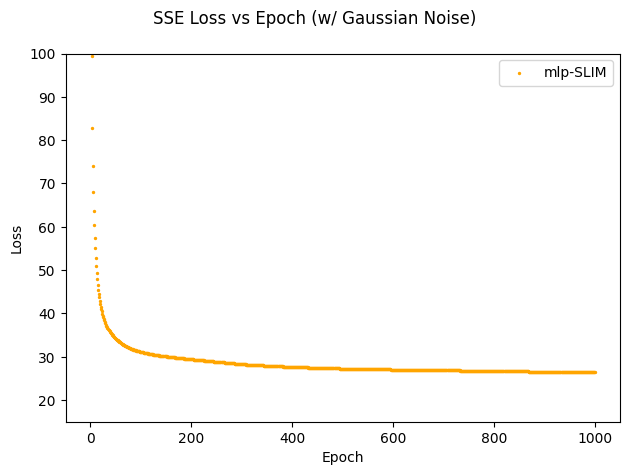

In [5]:
fig, ax = plt.subplots()

ax.scatter(x=epochs4, y=validation_losses4, s=2, c='orange', label='mlp-SLIM')

ax.set_ylabel('Loss')
ax.set_xlabel('Epoch')
ax.set_ylim(15, 100)
ax.legend()
fig.suptitle('SSE Loss vs Epoch (w/ Gaussian Noise)')
fig.tight_layout()
fig.savefig('/home/dajiang/smart-pixels-ml/plots/loss/loss_mlp-SLIM_manual-input-digitization_noise.png', dpi=300)
fig.show()

In [4]:
def get_all_thresholds(input_dir, model_type, initial_thresholds=[400, 1000, 2000], initial_levels=np.array([0,1,2,3]), threshold_offset=0.0, timeslices=2): 
    checkpoints = natsorted(os.listdir(input_dir))
    thresholds_1 = []
    thresholds_2 = []
    thresholds_3 = []
    
    if model_type == 'conv2d-MAX':
        model = CreateModel_Max_SoftQuantizer((16,16,timeslices), n_filters=5, pool_size=3, initial_thresholds=initial_thresholds, threshold_offset=threshold_offset, initial_levels=initial_levels)
    elif model_type =='conv2d-FULL':
        model = CreateModel_Full_SoftQuantizer((16,16,timeslices), n_filters=5, pool_size=3, initial_thresholds=initial_thresholds, threshold_offset=threshold_offset, initial_levels=initial_levels)
    elif model_type =='mlp-FULL':
        model = CreateModel_Full_SoftQuantizer((16,16,timeslices), initial_thresholds=initial_thresholds, threshold_offset=threshold_offset, initial_levels=initial_levels)
    elif model_type =='mlp-SLIM':
        model = CreateModel_Slim_SoftQuantizer((16,16,timeslices), initial_thresholds=initial_thresholds, threshold_offset=threshold_offset, initial_levels=initial_levels)
            
    for i in tqdm(range(len(checkpoints))):
        model.load_weights(f'{input_dir}/{checkpoints[i]}', by_name=True, skip_mismatch=True)
        sq_layer = model.get_layer(name="soft_quantizer_output")
        thresholds_1.append(sq_layer.thresholds.numpy()[0])
        thresholds_2.append(sq_layer.thresholds.numpy()[1])
        thresholds_3.append(sq_layer.thresholds.numpy()[2])
        
    return thresholds_1, thresholds_2, thresholds_3

In [7]:
thresholds_1, thresholds_2, thresholds_3 = get_all_thresholds('/data/dajiang/smart-pixels/weights/dataset_3src_16x16_weights/weights-50x12P5-bs5000-34c2da80-2t-conv2d_FULL-soft_quantizer-noise-checkpoints','conv2d-FULL')

100%|██████████| 1000/1000 [00:43<00:00, 23.14it/s]


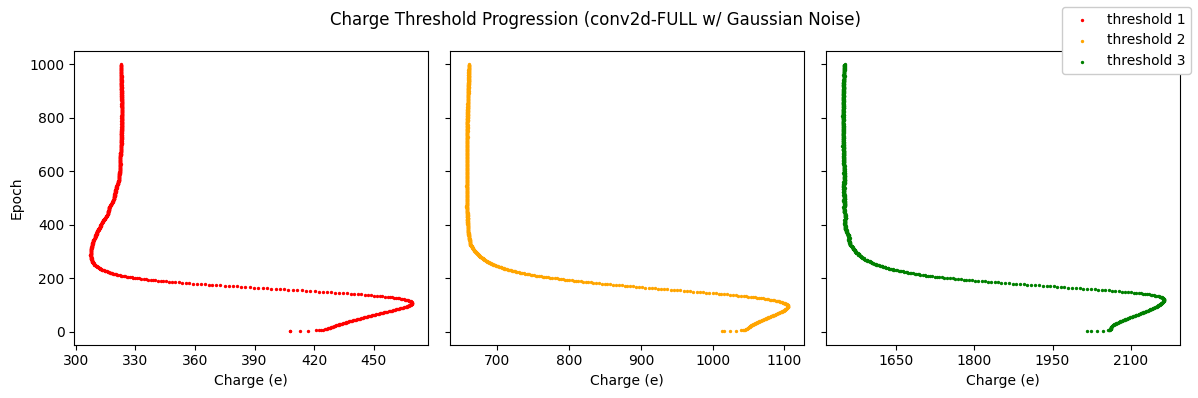

In [8]:
fig, ax = plt.subplots(1,3, figsize=(12,4), sharey=True)
epochs=np.arange(1,len(thresholds_1)+1,1)
ax[0].scatter(x=thresholds_1, y=epochs, s=2, c='red', label='threshold 1')
ax[1].scatter(x=thresholds_2, y=epochs, s=2, c='orange', label='threshold 2')
ax[2].scatter(x=thresholds_3, y=epochs, s=2, c='green', label='threshold 3')

ax[0].set_ylabel('Epoch')

ax[0].set_xlabel('Charge (e)')
ax[1].set_xlabel('Charge (e)')
ax[2].set_xlabel('Charge (e)')

ax[0].xaxis.set_major_locator(mticker.MaxNLocator(integer=False, nbins=6))
ax[1].xaxis.set_major_locator(mticker.MaxNLocator(integer=False, nbins=6))
ax[2].xaxis.set_major_locator(mticker.MaxNLocator(integer=False, nbins=6))

fig.legend(framealpha=1)
fig.suptitle('Charge Threshold Progression (conv2d-FULL w/ Gaussian Noise)')
fig.tight_layout()
fig.savefig('/home/dajiang/smart-pixels-ml/plots/charge_threshold_progression/thresholds_conv2d-FULL_noise.png', dpi=300)
fig.show()